# **Model 2 Parameters:**
## **Inputs:** SMILES strings of chemical structures
## **Outputs:** Predicted pDC50 values against ZBTB11 and IKZF1
## **Approach:** Multi-target Chemprop v2 with Optuna wrapper for hyperparameter tuning
### Chemprop native data splitting using astartes package to compute Bemis-Murcko scaffold of each molecule
* Scaffold-balanced, 80/10/10% train/validation/test
* Increased Optuna trials to 100 and epochs/trial to 50 for better and more consistent hyperparameter identification
* Additionally increased final model training epochs to 100

**Package installs and file loading**

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Colab Notebooks/ZBTB11 Degraders/model2"

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/ZBTB11 Degraders/model2


In [ ]:
!pip install optuna lightning chemprop

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.4/150.4 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 51.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import torch
import optuna
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from lightning import pytorch as pl
from chemprop import data, featurizers, models, nn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
from lightning.pytorch.loggers import CSVLogger

**Synthetic Data Generation**

Uncomment code chunk below if you want to test code adjustments with randomly generated dataset

In [ ]:
# print("Generating synthetic molecular glue dataset...")

# # 1. Generate 100 valid SMILES strings
# # We use a basic amide-phenyl scaffold and grow an aliphatic chain to create unique molecules
# smiles_list = [f"O=C(Nc1ccccc1)C{'C'*i}" for i in range(1, 41)] + \
#               [f"O=C(Nc1ccc(Cl)cc1)C{'C'*i}" for i in range(1, 31)] + \
#               [f"O=C(Nc1ccc(F)cc1)C{'C'*i}" for i in range(1, 31)]

# df = pd.DataFrame({'SMILES': smiles_list})

# # 2. Assign distinct splits (70 Train / 15 Val / 15 Test)
# df['Dataset'] = ['Train'] * 70 + ['Val'] * 15 + ['Test'] * 15

# # 3. Generate dummy ZBTB11 data
# # pDC50 between 5.0 (10 uM) and 9.0 (1 nM), Dmax between 20% and 100%
# np.random.seed(42) # For reproducible random numbers
# df['ZBTB11_pDC50'] = np.random.uniform(5.0, 9.0, 100)
# df['ZBTB11_Dmax'] = np.random.uniform(20.0, 100.0, 100)

# # 4. Generate dummy IKZF1 data
# df['IKZF1_pDC50'] = np.random.uniform(4.0, 8.0, 100)
# df['IKZF1_Dmax'] = np.random.uniform(0.0, 100.0, 100)

# # 5. Inject 'NaN' values to simulate Inactive Compounds
# # Let's pick 10 random molecules and make them completely inactive against IKZF1
# inactive_indices = np.random.choice(100, 10, replace=False)
# df.loc[inactive_indices, 'IKZF1_Dmax'] = 0.0
# df.loc[inactive_indices, 'IKZF1_pDC50'] = np.nan # This tests Chemprop's masking feature!

# # 6. Save to CSV
# csv_filename = "zbtb11_mgd_input.csv"
# df.to_csv(csv_filename, index=False)

# print(f"Successfully saved 100 test molecules to '{csv_filename}'.")
# print("\nSample of the generated data:")
# print(df.head())

**Model Training and Evaluation Pipeline**

Step 1: Parsing and splitting data natively with Chemprop...


/usr/local/lib/python3.12/dist-packages/astartes/main.py:325: ImperfectSplittingWarning: Actual train/test split differs from requested size. Requested train size of 0.80, got 0.81. Requested validation size of 0.10, got 0.09. Requested test size of 0.10, got 0.09. 
  warn(
[I 2026-03-05 04:49:58,250] A new study created in memory with name: no-name-47fd4bb4-0980-4a8b-9ecf-9dbe8e0f6894


Split complete! Train: 70, Val: 8, Test: 8

Step 2: Running Optuna to find the best model architecture...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilit

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  1.4 M │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │  1.9 M │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

...

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  2.6 M │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │  2.4 M │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 5.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.0 M                                                                                                
Total estimated model params size (MB): 20                                                                         
Modules in train mode: 26                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.



Discovered log columns: ['epoch', 'step', 'train_loss_epoch', 'train_loss_step', 'val/mse', 'val_loss']


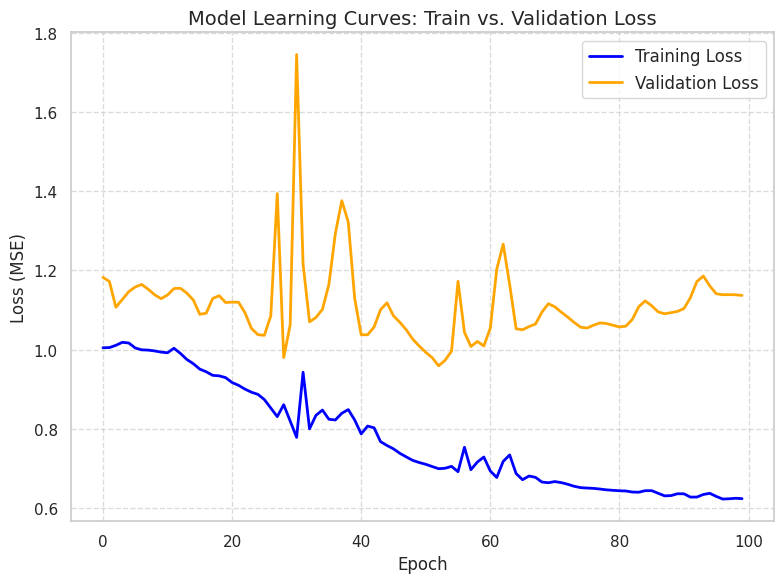

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Step 4: Predicting on the Test Set and calculating Efficiency Scores...


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.



--- Top Predicted Selective Compounds (Efficiency-based) ---
                                              SMILES  ZBTB11_Efficiency  \
7  O=C1CCC(N2C(C(C=CC(NC(N3CC(CCC3)C4=CC=C(OC)C=C...           0.320805   
4  O=C1C2=CC=C(NC(CN(CC3)CCN3C4=CC=C(OC)C=C4)=O)C...           0.400821   
0  O=C1C2=CC=C(NC(N(CCCC3=CC=C(OC)C=C3)C4CCCC4)=O...           0.957025   
5  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)C(NCCC4=CC=C(O...           1.451168   
1  O=C(N(C1CCC(NC1=O)=O)C2=O)C=C2NC3=CC=CC(C4CCN(...           2.257081   

   IKZF1_Efficiency  Selectivity_Score  
7          1.192946          -0.872141  
4          1.343041          -0.942220  
0          2.488501          -1.531476  
5          3.504436          -2.053267  
1          4.548274          -2.291193  

Step 5: Extracting learned 3D fingerprints from the Chemprop model...
Extracted fingerprints shape: (8, 1100)

Step 6: Reducing dimensions with UMAP and plotting...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


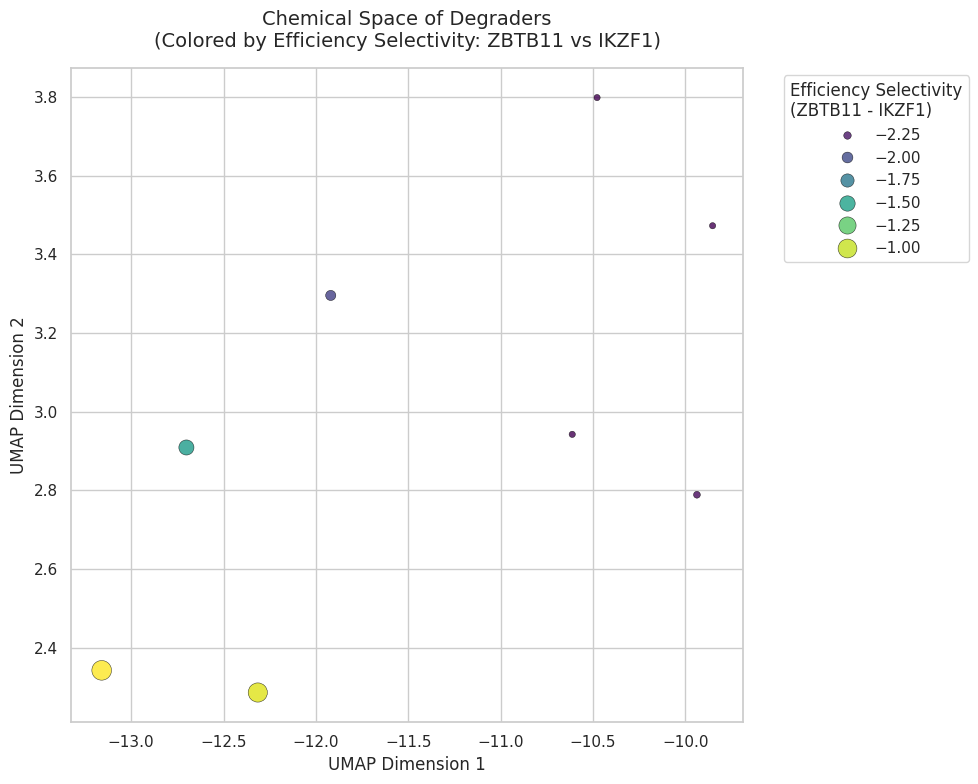


Step 7: Evaluating model performance metrics...

--- Regression Evaluation Metrics ---
    Endpoint  N_Valid_Points   RMSE    MAE     R²  Pearson_r
ZBTB11_pDC50               6  1.106  0.981 -2.790      0.636
 ZBTB11_Dmax               8 11.429  9.731  0.102      0.638
 IKZF1_pDC50               7  1.192  1.024 -0.597     -0.070
  IKZF1_Dmax               8 21.696 19.180 -2.034      0.059

Workflow complete!


In [ ]:
# ===================================================================
# STEP 1: LOAD, PARSE, AND SCAFFOLD-SPLIT DATA
# ===================================================================
print("Step 1: Parsing and splitting data natively with Chemprop...")

# Load full dataset
df = pd.read_csv("zbtb11_mgd_input.csv")

# Extract SMILES and 4 targets
smiles = df['SMILES'].tolist()
targets = df[['ZBTB11_pDC50', 'ZBTB11_Dmax', 'IKZF1_pDC50', 'IKZF1_Dmax']].values

# Create continuous MoleculeDatapoints
all_datapoints = [
    data.MoleculeDatapoint.from_smi(smi, y)
    for smi, y in zip(smiles, targets)
]

# Extract RDKit Mol objects to calculate Bemis-Murcko scaffolds
mols = [d.mol for d in all_datapoints]

# Generate scaffold-balanced split indices (80% Train, 10% Val, 10% Test)
train_idx, val_idx, test_idx = data.make_split_indices(
    mols,
    split="scaffold_balanced",
    sizes=(0.8, 0.1, 0.1),
    seed=42
)

# Apply indices to datapoints
train_data, val_data, test_data = data.split_data_by_indices(
    all_datapoints, train_idx, val_idx, test_idx
)

# Unpack the first replicate
train_datapoints = train_data[0]
val_datapoints = val_data[0]
test_datapoints = test_data[0]

# Create Datasets with standard Featurizer
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
train_dset = data.MoleculeDataset(train_datapoints, featurizer)
val_dset = data.MoleculeDataset(val_datapoints, featurizer)
test_dset = data.MoleculeDataset(test_datapoints, featurizer)

# Normalize targets
output_scaler = train_dset.normalize_targets()
val_dset.normalize_targets(output_scaler)
test_dset.normalize_targets(output_scaler)
output_transform = nn.transforms.UnscaleTransform.from_standard_scaler(output_scaler)

# Build PyTorch DataLoaders
train_loader = data.build_dataloader(train_dset, shuffle=True)
val_loader = data.build_dataloader(val_dset, shuffle=False)
test_loader = data.build_dataloader(test_dset, shuffle=False)

print(f"Split complete! Train: {len(train_dset)}, Val: {len(val_dset)}, Test: {len(test_dset)}")


# ===================================================================
# STEP 2: HYPERPARAMETER TUNING WITH OPTUNA
# ===================================================================
print("\nStep 2: Running Optuna to find the best model architecture...")

def objective(trial):
    depth = trial.suggest_int("depth", 2, 6)
    d_h = trial.suggest_int("d_h", 300, 1200, step=100)
    dropout = trial.suggest_float("dropout", 0.0, 0.4, step=0.1)
    n_layers = trial.suggest_int("n_layers", 1, 3)

    mp = nn.BondMessagePassing(depth=depth, d_h=d_h)
    agg = nn.MeanAggregation()

    ffn = nn.RegressionFFN(
        n_tasks=4,
        input_dim=mp.output_dim,
        hidden_dim=d_h,
        n_layers=n_layers,
        dropout=dropout,
        output_transform=output_transform
    )
    chemprop_model = models.MPNN(mp, agg, ffn)

    trainer = pl.Trainer(
        accelerator="auto", # Automatically uses GPU if available
        max_epochs=50,
        enable_checkpointing=False,
        enable_progress_bar=False,
        logger=False
    )
    trainer.fit(chemprop_model, train_loader, val_loader)

    return trainer.callback_metrics["val_loss"].item()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)
print(f"Best hyperparameters found: {study.best_params}")


# ===================================================================
# STEP 3: TRAIN FINAL MODEL & PLOT LOSS CURVES
# ===================================================================
print("\nStep 3: Training the final model and monitoring loss...")

best = study.best_params

final_mp = nn.BondMessagePassing(depth=best["depth"], d_h=best["d_h"])
final_agg = nn.MeanAggregation()

final_ffn = nn.RegressionFFN(
    n_tasks=4,
    input_dim=final_mp.output_dim,
    hidden_dim=best["d_h"],
    n_layers=best["n_layers"],
    dropout=best["dropout"],
    output_transform=output_transform
)
final_model = models.MPNN(final_mp, final_agg, final_ffn)

# 1. Set up the CSV Logger
logger = CSVLogger("training_logs", name="chemprop_model")

final_trainer = pl.Trainer(
    accelerator="auto",
    max_epochs=100,
    logger=logger, # <--- Attach the logger here
    enable_progress_bar=True,
    enable_checkpointing=True
)

# Train the model
final_trainer.fit(final_model, train_loader, val_loader)

# 2. Extract and Plot the Loss Curves
metrics_file = f"{logger.log_dir}/metrics.csv"
metrics_df = pd.read_csv(metrics_file)

print(f"\nDiscovered log columns: {metrics_df.columns.tolist()}")

# Dynamically find the correct column names for train and val loss
train_cols = [c for c in metrics_df.columns if 'train' in c.lower() and 'loss' in c.lower()]
val_cols = [c for c in metrics_df.columns if 'val' in c.lower() and 'loss' in c.lower()]

# Chemprop sometimes logs training loss simply as 'loss'
train_col = train_cols[0] if train_cols else ('loss' if 'loss' in metrics_df.columns else None)
val_col = val_cols[0] if val_cols else None

if train_col and val_col:
    # Group by epoch and drop NaNs (since Lightning logs train/val on different rows)
    train_loss = metrics_df[['epoch', train_col]].dropna().groupby('epoch').mean()
    val_loss = metrics_df[['epoch', val_col]].dropna().groupby('epoch').mean()

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.plot(train_loss.index, train_loss[train_col], label='Training Loss', color='blue', linewidth=2)
    plt.plot(val_loss.index, val_loss[val_col], label='Validation Loss', color='orange', linewidth=2)

    plt.title("Model Learning Curves: Train vs. Validation Loss", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss (MSE)", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig("learning_curves.png", dpi=300)
    plt.show()
else:
    print("\nError: Could not find both train and validation loss columns in the logs.")

# ===================================================================
# STEP 4: PREDICT & CALCULATE DEGRADATION EFFICIENCY SCORE
# ===================================================================
print("\nStep 4: Predicting on the Test Set and calculating Efficiency Scores...")

preds = final_trainer.predict(final_model, test_loader)
preds_tensor = torch.concat(preds, axis=0)

test_results_df = pd.DataFrame(
    preds_tensor.numpy(),
    columns=[
        'Pred_ZBTB11_pDC50', 'Pred_ZBTB11_Dmax',
        'Pred_IKZF1_pDC50', 'Pred_IKZF1_Dmax'
    ]
)

# Extract SMILES dynamically from the test datapoints
test_smiles = [dp.name for dp in test_datapoints]
test_results_df.insert(0, 'SMILES', test_smiles)

# Calculate Degradation Efficiency
test_results_df['ZBTB11_Efficiency'] = test_results_df['Pred_ZBTB11_pDC50'] * (test_results_df['Pred_ZBTB11_Dmax'] / 100)
test_results_df['IKZF1_Efficiency'] = test_results_df['Pred_IKZF1_pDC50'] * (test_results_df['Pred_IKZF1_Dmax'] / 100)

# Final Selectivity Score
test_results_df['Selectivity_Score'] = test_results_df['ZBTB11_Efficiency'] - test_results_df['IKZF1_Efficiency']

test_results_df = test_results_df.sort_values(by='Selectivity_Score', ascending=False)
print("\n--- Top Predicted Selective Compounds (Efficiency-based) ---")
print(test_results_df[['SMILES', 'ZBTB11_Efficiency', 'IKZF1_Efficiency', 'Selectivity_Score']].head())
test_results_df.to_csv("zbtb11_mgd_output.csv", index=False)


# ===================================================================
# STEP 5: EXTRACT LEARNED FINGERPRINTS FROM THE MODEL
# ===================================================================
print("\nStep 5: Extracting learned 3D fingerprints from the Chemprop model...")

# Bring model to CPU for frictionless extraction from batch structures
final_model.cpu()
final_model.eval()

learned_fingerprints = []

with torch.no_grad():
    for batch in test_loader:
        molecule_embeddings = final_model.fingerprint(batch.bmg, batch.V_d, batch.X_d)
        learned_fingerprints.append(molecule_embeddings.numpy())

embeddings_array = np.vstack(learned_fingerprints)
print(f"Extracted fingerprints shape: {embeddings_array.shape}")


# ===================================================================
# STEP 6: UMAP DIMENSIONALITY REDUCTION & PLOTTING
# ===================================================================
print("\nStep 6: Reducing dimensions with UMAP and plotting...")

reducer = umap.UMAP(n_neighbors=min(15, len(embeddings_array) - 1), min_dist=0.1, metric='euclidean', random_state=42)
embeddings_2d = reducer.fit_transform(embeddings_array)

# Re-sort results dataframe by original index to align with extracted embeddings
test_results_df = test_results_df.sort_index()

test_results_df['UMAP_1'] = embeddings_2d[:, 0]
test_results_df['UMAP_2'] = embeddings_2d[:, 1]

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    data=test_results_df,
    x='UMAP_1',
    y='UMAP_2',
    hue='Selectivity_Score',
    palette='viridis',
    size='Selectivity_Score',
    sizes=(20, 200),
    alpha=0.8,
    edgecolor="black"
)

plt.title("Chemical Space of Degraders\n(Colored by Efficiency Selectivity: ZBTB11 vs IKZF1)", fontsize=14, pad=15)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Efficiency Selectivity\n(ZBTB11 - IKZF1)")
plt.tight_layout()
plt.savefig("efficiency_selectivity_umap.png", dpi=300, bbox_inches='tight')
plt.show()


# ===================================================================
# STEP 7: EVALUATE REGRESSION METRICS
# ===================================================================
print("\nStep 7: Evaluating model performance metrics...")


true_cols = ['ZBTB11_pDC50', 'ZBTB11_Dmax', 'IKZF1_pDC50', 'IKZF1_Dmax']
pred_cols = ['Pred_ZBTB11_pDC50', 'Pred_ZBTB11_Dmax', 'Pred_IKZF1_pDC50', 'Pred_IKZF1_Dmax']

# Extract true targets dynamically from test datapoints
y_true_array = np.array([dp.y for dp in test_datapoints])
evaluation_results = []

for idx, (true_col, pred_col) in enumerate(zip(true_cols, pred_cols)):
    y_true = y_true_array[:, idx]
    y_pred = test_results_df[pred_col].values

    # Mask NaNs
    valid_mask = ~np.isnan(y_true)
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    if len(y_true_valid) > 1:
        rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
        mae = mean_absolute_error(y_true_valid, y_pred_valid)
        r2 = r2_score(y_true_valid, y_pred_valid)
        pearson_r, _ = pearsonr(y_true_valid, y_pred_valid)
    else:
        rmse, mae, r2, pearson_r = np.nan, np.nan, np.nan, np.nan

    evaluation_results.append({
        'Endpoint': true_col,
        'N_Valid_Points': len(y_true_valid),
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'R²': round(r2, 3),
        'Pearson_r': round(pearson_r, 3)
    })

metrics_df = pd.DataFrame(evaluation_results)
metrics_df.to_csv("zbtb11_mgd_model_metrics.csv", index=False)
print("\n--- Regression Evaluation Metrics ---")
print(metrics_df.to_string(index=False))
print("\nWorkflow complete!")